# 08 — End-to-End Pipeline

This notebook walks through a complete Sentinel pipeline, connecting all modules from raw logs to visualized anomaly results. The goal is to show how the pieces fit together in a realistic workflow.

### Pipeline stages

| Stage | Module | What it does |
|-------|--------|--------------|
| 1. Ingestion | `sentinel.ingestion` | Parse raw log files into a structured DataFrame |
| 2. Transformation | `sentinel.transformer` | Aggregate raw events into time-windowed features |
| 3. Exploration | `sentinel.explorer` | Assess signal quality and check for distribution drift |
| 4. Detection | `sentinel.detectors` | Run anomaly detection on the transformed features |
| 5. Visualization | `sentinel.visualization` | Plot results with static, interactive, and interpretability charts |

### Why this order matters

Each stage builds on the previous one:
- **Ingestion** converts unstructured text into tabular data the rest of the pipeline can consume
- **Transformation** reduces noise and creates meaningful features (e.g., rolling averages smooth out per-minute jitter)
- **Exploration** catches data quality issues *before* you invest compute in detection
- **Detection** applies the actual anomaly algorithm on clean, feature-engineered data
- **Visualization** lets you validate results against known incidents and communicate findings

All data in this notebook is generated synthetically inline.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

---
## Step 1: Ingestion

The ingestion stage converts raw log files into structured DataFrames. Sentinel provides built-in parsers for common formats (WAS, HSM, IBM MQ, HDC) and a `BaseLogParser` class for custom formats.

Here we define a simple custom parser that reads pipe-delimited log lines with the format:
```
timestamp|cpu_value|memory_value|status
```

### Synthetic log generation

We generate 1000 log lines (~3.5 days at 5-minute intervals) with:
- **CPU and memory** following sinusoidal daily patterns (simulating real server load cycles)
- **Status codes**: mostly `OK`, with some `WARN` and `ERROR`
- **An anomaly window** (indices 400-430) where CPU and memory spike and all statuses become `ERROR`

In [2]:
from sentinel.ingestion import BaseLogParser

class PipelineLogParser(BaseLogParser):
    """Parses pipe-delimited server log lines."""

    def parse(self):
        records = []
        with open(self.file_path, 'r') as f:
            for line in f:
                parts = line.strip().split('|')
                if len(parts) == 4:
                    records.append({
                        'timestamp': parts[0],
                        'cpu': float(parts[1]),
                        'memory': float(parts[2]),
                        'status': parts[3],
                    })
        return pd.DataFrame(records)

print("Custom parser defined.")

Custom parser defined.


In [3]:
import tempfile, os

# Generate synthetic log file
n_logs = 1000
timestamps = pd.date_range('2025-01-15 00:00', periods=n_logs, freq='5min')
cpu_vals = 45 + 15 * np.sin(2 * np.pi * np.arange(n_logs) / 288) + np.random.normal(0, 3, n_logs)
mem_vals = 2048 + 200 * np.sin(2 * np.pi * np.arange(n_logs) / 144) + np.random.normal(0, 40, n_logs)
statuses = np.random.choice(['OK', 'OK', 'OK', 'WARN', 'ERROR'], n_logs)

# Inject anomaly window
anomaly_window = slice(400, 430)
cpu_vals[anomaly_window] += np.random.uniform(25, 45, 30)
mem_vals[anomaly_window] += np.random.uniform(800, 1500, 30)
statuses[400:430] = 'ERROR'

# Write to temp file
tmpdir = tempfile.mkdtemp()
log_path = os.path.join(tmpdir, 'server.log')
with open(log_path, 'w') as f:
    for ts, c, m, s in zip(timestamps, cpu_vals, mem_vals, statuses):
        f.write(f"{ts}|{c:.2f}|{m:.2f}|{s}\n")

print(f"Generated {n_logs} log lines at {log_path}")
print(f"Anomaly window: indices 400-430 ({timestamps[400]} → {timestamps[429]})")

Generated 1000 log lines at /var/folders/ck/pscdwm851rb3zr3vrmnv_hwm0000gr/T/tmpqm7a6kwv/server.log
Anomaly window: indices 400-430 (2025-01-16 09:20:00 → 2025-01-16 11:45:00)


In [4]:
# Parse the log file
parser = PipelineLogParser(log_path)
raw_df = parser.parse()
raw_df['timestamp'] = pd.to_datetime(raw_df['timestamp'])
raw_df = raw_df.set_index('timestamp')

print(f"Parsed DataFrame: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")
print(f"Columns: {list(raw_df.columns)}")
print(f"Time range: {raw_df.index[0]} → {raw_df.index[-1]}")
raw_df.head()

Parsed DataFrame: 1000 rows, 3 columns
Columns: ['cpu', 'memory', 'status']
Time range: 2025-01-15 00:00:00 → 2025-01-18 11:15:00


,cpu,memory,status
timestamp,,,
2025-01-15 00:00:00,46.49,2103.97,OK
2025-01-15 00:05:00,44.91,2093.71,OK
2025-01-15 00:10:00,47.60,2067.82,OK
2025-01-15 00:15:00,50.55,2048.23,WARN
2025-01-15 00:20:00,45.60,2110.66,ERROR


---
## Step 2: Transformation

Raw log data is typically too noisy for direct anomaly detection. The transformation stage creates smoother, more informative features through aggregation.

We apply two types of transformation:

### 2.1 Rolling Aggregation (numeric columns)

`RollingAggregator` computes rolling window statistics over numeric columns. With a window of 12 samples at 5-minute intervals, we get 1-hour rolling means.

### 2.2 String Aggregation (categorical columns)

`StringAggregator` aggregates categorical data (like status codes) into time windows, producing counts and distributions.

In [5]:
from sentinel.transformer import RollingAggregator

# Rolling aggregation on numeric columns
numeric_df = raw_df[['cpu', 'memory']].copy()

agg = RollingAggregator(
    window_size=12,  # 1-hour window (12 x 5min)
    aggregation_functions='mean',
)
rolled_df = agg.fit_transform(numeric_df)

print(f"Rolled DataFrame: {rolled_df.shape}")
print(f"Columns: {list(rolled_df.columns)}")
rolled_df.head(15)

Rolled DataFrame: (1000, 4)
Columns: ['cpu', 'memory', 'cpu_rolling_mean', 'memory_rolling_mean']


,cpu,memory,cpu_rolling_mean,memory_rolling_mean
timestamp,,,,
2025-01-15 00:00:00,46.49,2103.97,NaN,NaN
2025-01-15 00:05:00,44.91,2093.71,NaN,NaN
2025-01-15 00:10:00,47.60,2067.82,NaN,NaN
2025-01-15 00:15:00,50.55,2048.23,NaN,NaN
2025-01-15 00:20:00,45.60,2110.66,NaN,NaN
2025-01-15 00:25:00,45.93,2107.03,NaN,NaN
2025-01-15 00:30:00,51.70,2135.57,NaN,NaN
2025-01-15 00:35:00,49.58,2133.55,NaN,NaN
2025-01-15 00:40:00,46.20,2158.39,NaN,NaN


In [6]:
from sentinel.transformer import StringAggregator

# String aggregation on status column
status_df = raw_df[['status']].copy().reset_index()
status_df.columns = ['timestamp', 'status']

str_agg = StringAggregator(status_df, timestamp_column='timestamp')
status_counts = str_agg.create_time_aggregation(
    time_window='1h',
    column_metrics={'status': ['count', 'nunique']},
    category_count_columns={'status': ['OK', 'WARN', 'ERROR']},
)

print(f"Status counts shape: {status_counts.shape}")
print(f"Columns: {list(status_counts.columns)}")
status_counts.head(10)

Status counts shape: (84, 8)
Columns: ['status_count', 'status_nunique', 'status_OK_count', 'status_WARN_count', 'status_ERROR_count', 'avg_time_between_events_seconds', 'min_time_between_events_seconds', 'max_time_between_events_seconds']


,status_count,status_nunique,status_OK_count,status_WARN_count,status_ERROR_count,avg_time_between_events_seconds,min_time_between_events_seconds,max_time_between_events_seconds
2025-01-15 00:00:00,12,3,7,1,4,300.0,300.0,300.0
2025-01-15 01:00:00,12,3,8,3,1,300.0,300.0,300.0
2025-01-15 02:00:00,12,2,6,0,6,300.0,300.0,300.0
2025-01-15 03:00:00,12,2,7,5,0,300.0,300.0,300.0
2025-01-15 04:00:00,12,3,7,3,2,300.0,300.0,300.0
2025-01-15 05:00:00,12,3,9,1,2,300.0,300.0,300.0
2025-01-15 06:00:00,12,3,9,2,1,300.0,300.0,300.0
2025-01-15 07:00:00,12,3,7,3,2,300.0,300.0,300.0
2025-01-15 08:00:00,12,3,6,1,5,300.0,300.0,300.0
2025-01-15 09:00:00,12,3,7,4,1,300.0,300.0,300.0


### Visualize the transformed features

The rolling mean smooths out the noise while preserving the anomaly spike around the injected window.

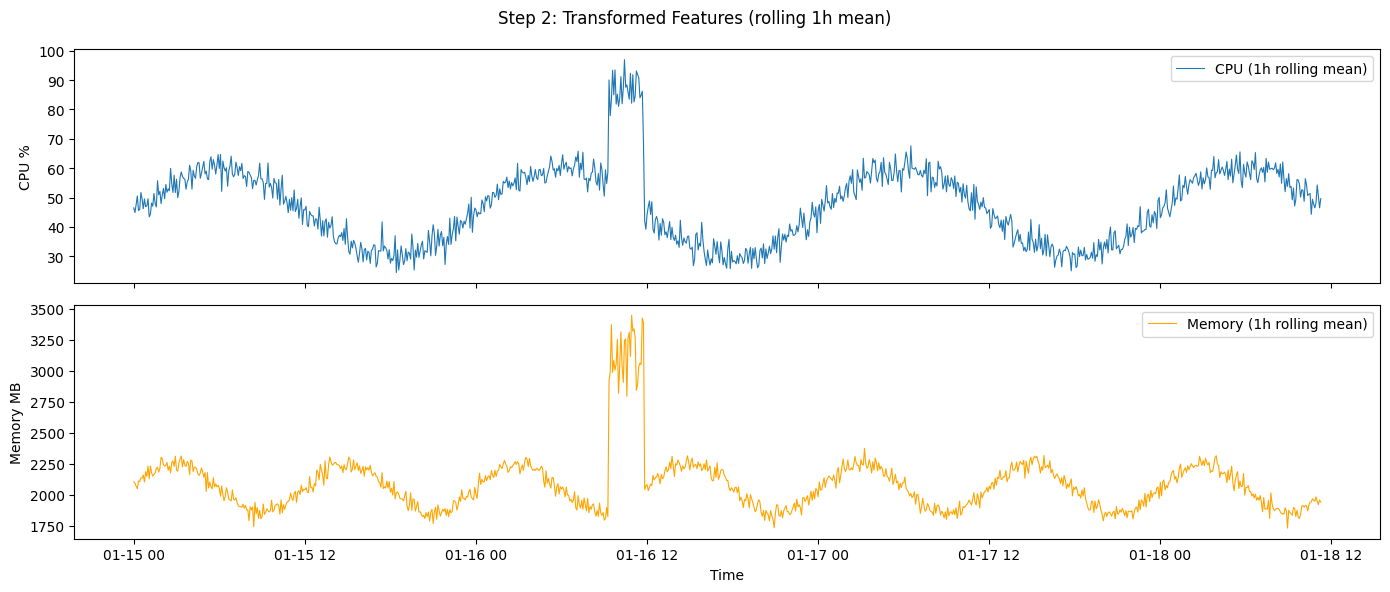

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(rolled_df.index, rolled_df.iloc[:, 0], label='CPU (1h rolling mean)', linewidth=0.8)
ax1.set_ylabel('CPU %')
ax1.legend()

ax2.plot(rolled_df.index, rolled_df.iloc[:, 1], label='Memory (1h rolling mean)', linewidth=0.8, color='orange')
ax2.set_ylabel('Memory MB')
ax2.set_xlabel('Time')
ax2.legend()

plt.suptitle('Step 2: Transformed Features (rolling 1h mean)')
plt.tight_layout()
plt.show()

---
## Step 3: Exploration

Before investing compute in anomaly detection, it's worth checking whether the data actually contains enough signal. The exploration stage answers:

- **Is there enough data?** (min_entries check)
- **Is there enough variance?** (min_variance check)
- **Are there missing values?** (min_non_null_pct check)
- **Are there IQR outliers?** (anomaly_pct check)

We also check for **distribution drift** between windows using the Kolmogorov-Smirnov test.

In [8]:
from sentinel.explorer import SignalDiagnostics, Thresholds

# Drop NaN rows from rolling aggregation
clean_df = rolled_df.dropna()

# Run signal diagnostics
diag = SignalDiagnostics(
    df=clean_df,
    columns=list(clean_df.columns),
)
report = diag.quality_report(thresholds=Thresholds.relaxed())

print(f"Overall: {report}")
print(f"Score: {report.score:.0%}")
print()
for check in report.checks:
    status = 'PASS' if check.passed else 'FAIL'
    print(f"  [{status}] {check.name} | {check.column}: {check.value:.4f} (threshold: {check.threshold})")

print()
print(report.interpret())

Overall: QualityReport(FAILED, 16 checks, 1 failed)
Score: 94%

  [PASS] min_entries | cpu: 989.0000 (threshold: 100)
  [PASS] min_non_null_pct | cpu: 100.0000 (threshold: 80.0)
  [PASS] min_variance | cpu: 169.4127 (threshold: 0.001)
  [PASS] anomaly_pct | cpu: 1.1122 (threshold: 1.0)
  [PASS] min_entries | memory: 989.0000 (threshold: 100)
  [PASS] min_non_null_pct | memory: 100.0000 (threshold: 80.0)
  [PASS] min_variance | memory: 56254.5212 (threshold: 0.001)
  [PASS] anomaly_pct | memory: 3.0334 (threshold: 1.0)
  [PASS] min_entries | cpu_rolling_mean: 989.0000 (threshold: 100)
  [PASS] min_non_null_pct | cpu_rolling_mean: 100.0000 (threshold: 80.0)
  [PASS] min_variance | cpu_rolling_mean: 155.3917 (threshold: 0.001)
  [FAIL] anomaly_pct | cpu_rolling_mean: 0.0000 (threshold: 1.0)
  [PASS] min_entries | memory_rolling_mean: 989.0000 (threshold: 100)
  [PASS] min_non_null_pct | memory_rolling_mean: 100.0000 (threshold: 80.0)
  [PASS] min_variance | memory_rolling_mean: 47777.3898

In [9]:
from sentinel.explorer import detect_drift

# Check drift for each numeric column
for col in clean_df.columns:
    drift_results = detect_drift(
        df=clean_df,
        column=col,
        window=len(clean_df) // 4,
    )
    print(f"\n{col}:")
    for r in drift_results:
        flag = 'DRIFT' if r['drifted'] else 'stable'
        print(f"  Window [{r['start_idx']}:{r['end_idx']}] — KS={r['statistic']:.4f}, p={r['p_value']:.4f} → {flag}")


cpu:
  Window [247:494] — KS=0.1538, p=0.0057 → DRIFT
  Window [494:741] — KS=0.1134, p=0.0836 → stable
  Window [741:988] — KS=0.0567, p=0.8235 → stable

memory:
  Window [247:494] — KS=0.1862, p=0.0004 → DRIFT
  Window [494:741] — KS=0.1417, p=0.0139 → DRIFT
  Window [741:988] — KS=0.1174, p=0.0664 → stable

cpu_rolling_mean:
  Window [247:494] — KS=0.2105, p=0.0000 → DRIFT
  Window [494:741] — KS=0.1093, p=0.1045 → stable
  Window [741:988] — KS=0.0810, p=0.3936 → stable

memory_rolling_mean:
  Window [247:494] — KS=0.1862, p=0.0004 → DRIFT
  Window [494:741] — KS=0.1619, p=0.0030 → DRIFT
  Window [741:988] — KS=0.1174, p=0.0664 → stable


---
## Step 4: Detection

With clean, feature-engineered data and confirmed signal quality, we run anomaly detection using `IsolationForestDetector` with `contamination=0.05`.

The detector returns both binary predictions (`-1` = anomaly, `1` = normal) and continuous anomaly scores via `decision_function()`.

In [10]:
from sentinel.detectors import IsolationForestDetector

# Prepare detection data
detect_df = clean_df.copy()

detector = IsolationForestDetector(contamination=0.05, random_state=42)
detector.fit(detect_df)

predictions = detector.predict(detect_df)
# decision_function returns negative scores for anomalies; we negate for intuitive "higher = more anomalous"
scores = -detector.decision_function(detect_df)

detect_df['anomaly'] = predictions
detect_df['scores'] = scores

n_anomalies = (predictions == -1).sum()
print(f"Detected {n_anomalies} anomalies out of {len(detect_df)} samples ({100*n_anomalies/len(detect_df):.1f}%)")

Detected 50 anomalies out of 989 samples (5.1%)


/Users/jomaver/Desktop/Code/sentinel/.venv/lib/python3.12/site-packages/rrcf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Detection results overview

Quick matplotlib overview before using the full visualization module.

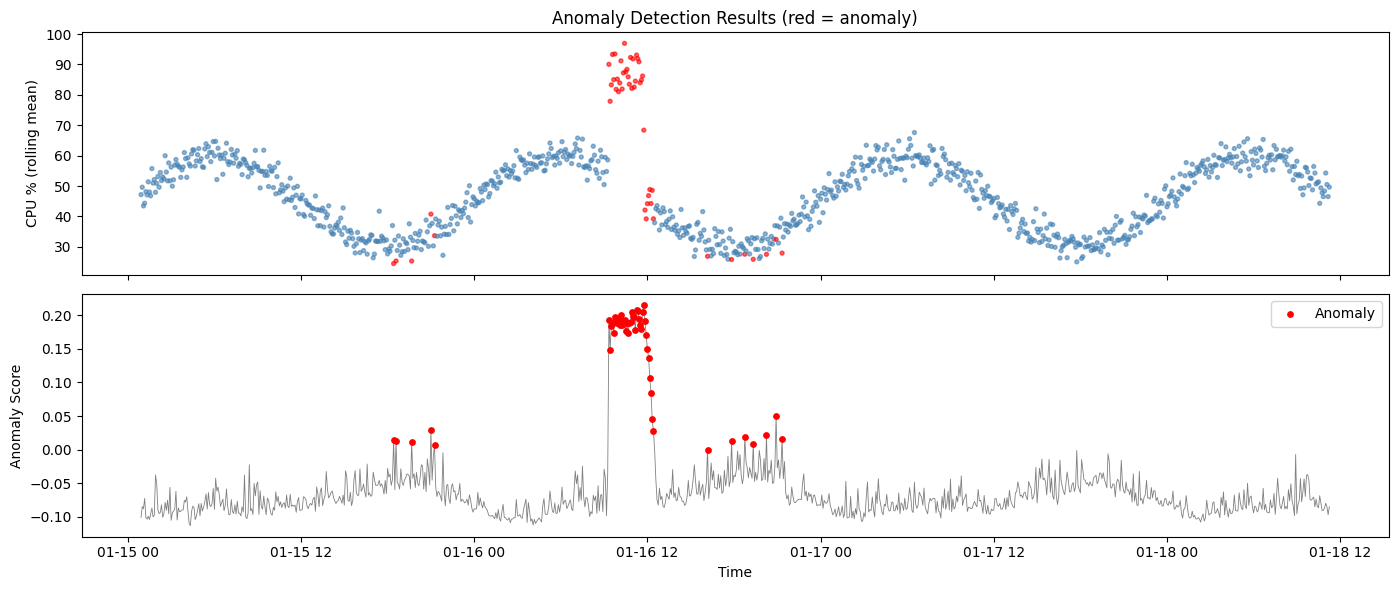

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

colors = ['red' if a == -1 else 'steelblue' for a in detect_df['anomaly']]
ax1.scatter(detect_df.index, detect_df.iloc[:, 0], c=colors, s=8, alpha=0.6)
ax1.set_ylabel('CPU % (rolling mean)')
ax1.set_title('Anomaly Detection Results (red = anomaly)')

ax2.plot(detect_df.index, detect_df['scores'], linewidth=0.6, color='gray')
anomaly_mask = detect_df['anomaly'] == -1
ax2.scatter(detect_df.index[anomaly_mask], detect_df['scores'][anomaly_mask],
            color='red', s=15, zorder=5, label='Anomaly')
ax2.set_ylabel('Anomaly Score')
ax2.set_xlabel('Time')
ax2.legend()

plt.tight_layout()
plt.show()

---
## Step 5: Visualization

Finally, we use `AnomalyVisualizer` for polished output. We demonstrate the full suite of visualization methods:

1. `plot_static()` — score timeline with threshold and incident overlay
2. `plot_dynamic()` — interactive Plotly chart
3. `plot_score_distribution()` — histogram to assess class separation
4. `plot_features()` — feature time series with anomaly markers

Since we know the exact anomaly window we injected, we create an incidents DataFrame to overlay on the charts.

In [12]:
from sentinel.visualization import AnomalyVisualizer

# Create incidents DataFrame from the known anomaly window
incidents_df = pd.DataFrame({
    'start_time': [timestamps[400]],
    'end_time': [timestamps[429]],
    'Servicio': ['Injected anomaly window'],
})

viz = AnomalyVisualizer(
    anomaly_df=detect_df,
    incidents_df=incidents_df,
    score_col='scores',
    anomaly_col='anomaly',
)

/Users/jomaver/Desktop/Code/sentinel/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 5.1 Static plot with threshold

The threshold line helps visually assess where the cutoff falls relative to normal and anomalous scores.

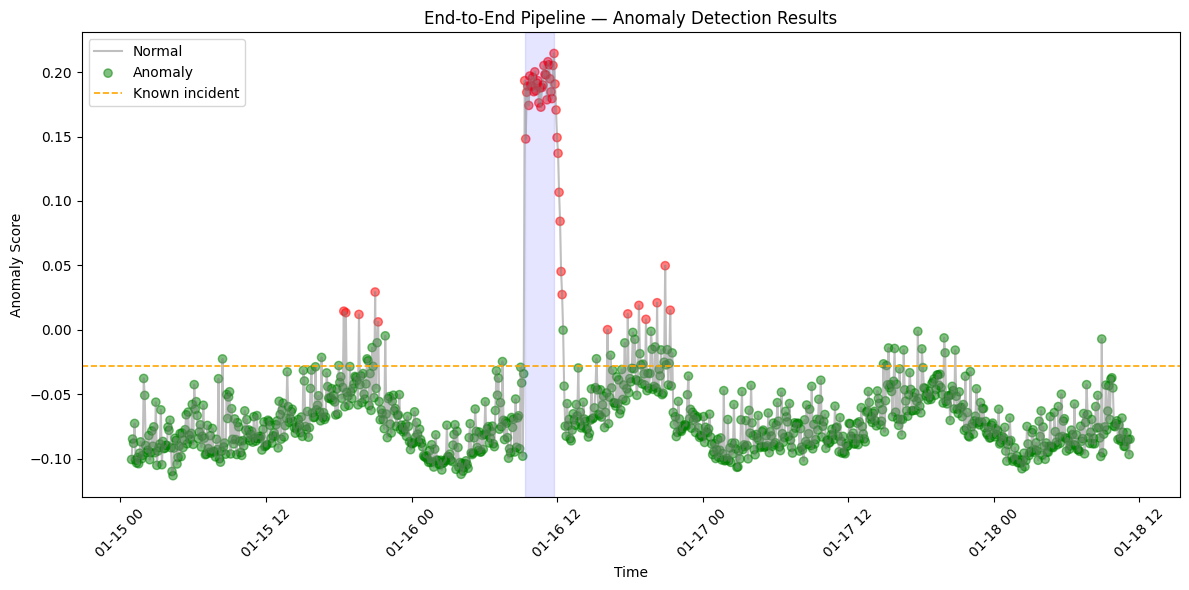

In [13]:
# Calculate a threshold from normal scores
normal_scores = detect_df.loc[detect_df['anomaly'] != -1, 'scores']
threshold = normal_scores.mean() + 2 * normal_scores.std()

viz.plot_static(
    threshold=threshold,
    title='End-to-End Pipeline — Anomaly Detection Results',
    xlabel='Time',
    ylabel='Anomaly Score',
    legend_labels=['Normal', 'Anomaly', 'Known incident'],
)

### 5.2 Interactive plot with threshold

Hover over points to see exact timestamps and scores. Zoom into the incident window for detail.

In [14]:
viz.plot_dynamic(
    threshold=threshold,
    title='End-to-End Pipeline — Interactive View',
    xaxis_title='Time',
    yaxis_title='Anomaly Score',
)

### 5.3 Score distribution

The histogram shows how well-separated the normal and anomaly score distributions are. A clear gap means the detector can reliably distinguish anomalies.

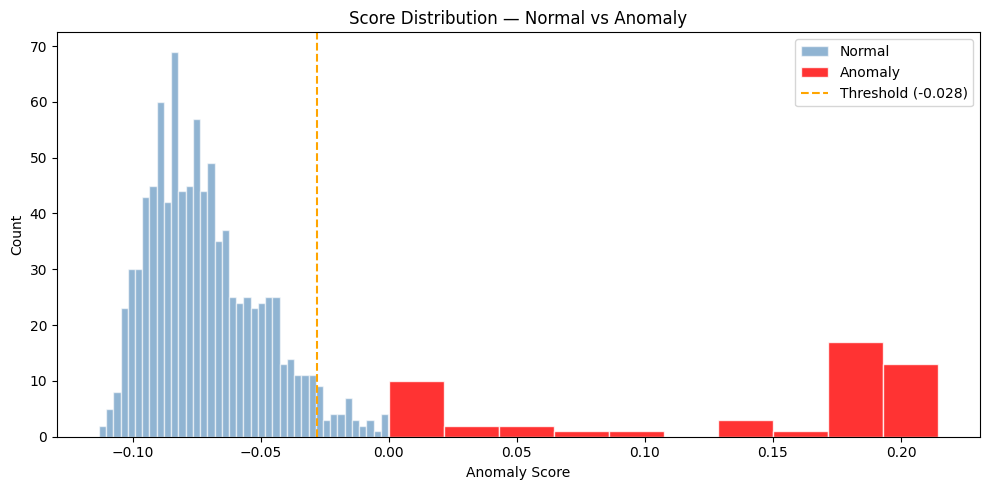

In [15]:
viz.plot_score_distribution(
    bins=40,
    threshold=threshold,
    title='Score Distribution — Normal vs Anomaly',
)

### 5.4 Feature values with anomaly markers

This plot shows the original feature values over time with red markers on samples classified as anomalies. It reveals *what happened* in the data when an anomaly was detected — essential for root cause analysis.

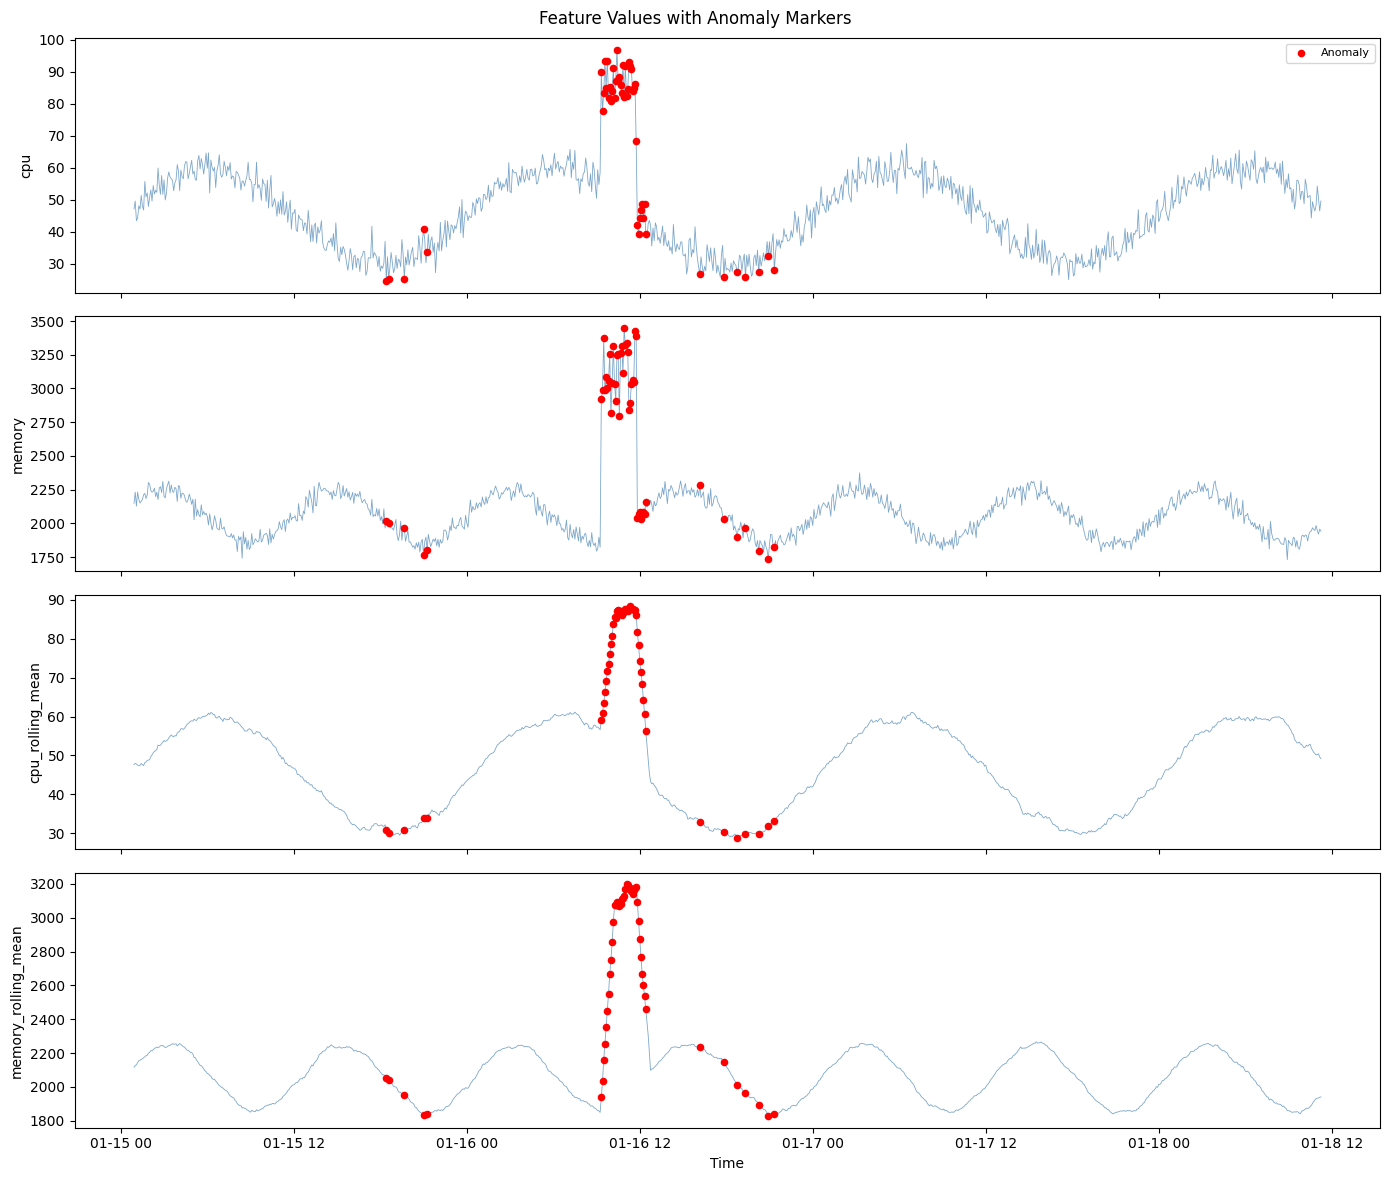

In [16]:
viz.plot_features(
    title='Feature Values with Anomaly Markers',
)

---
## Step 6: Interpretability (SHAP)

As a bonus step, we use `SHAPVisualizer` to understand *why* the Isolation Forest flagged certain samples. This closes the loop from detection to explanation.

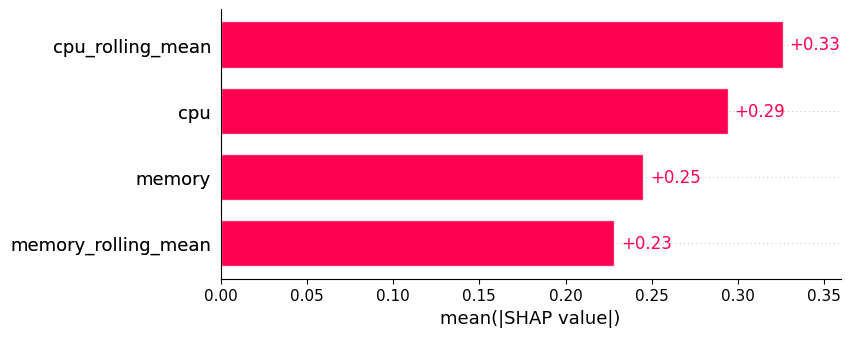

In [17]:
from sentinel.visualization import SHAPVisualizer

# SHAPVisualizer needs the feature columns only (no scores/anomaly)
feature_cols = [c for c in detect_df.columns if c not in ('scores', 'anomaly')]
X_features = detect_df[feature_cols]

shap_viz = SHAPVisualizer(detector)

# Global feature importance
shap_viz.plot_bar(X_features)

Explaining anomaly at index 210:
cpu                      24.490000
memory                 2017.100000
cpu_rolling_mean         30.741667
memory_rolling_mean    2049.745833
Name: 2025-01-15 18:25:00, dtype: float64


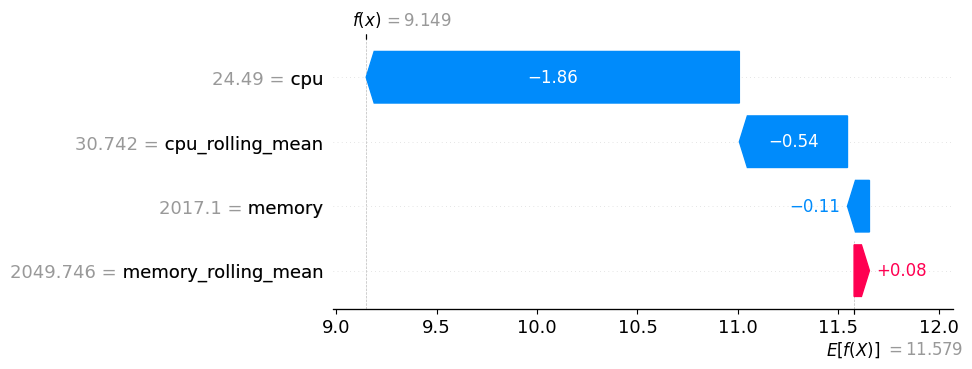

In [18]:
# Waterfall for the first detected anomaly
anomaly_indices = np.where(predictions == -1)[0]
if len(anomaly_indices) > 0:
    idx = anomaly_indices[0]
    print(f"Explaining anomaly at index {idx}:")
    print(X_features.iloc[idx])
    shap_viz.plot_waterfall(X_features, sample_index=idx)

---
## Pipeline Summary

| Step | Module | Input | Output |
|------|--------|-------|--------|
| 1. Ingestion | `sentinel.ingestion` | Raw log file | Structured DataFrame |
| 2. Transformation | `sentinel.transformer` | Raw DataFrame | Aggregated features |
| 3. Exploration | `sentinel.explorer` | Feature DataFrame | Quality report + drift analysis |
| 4. Detection | `sentinel.detectors` | Clean features | Anomaly scores + predictions |
| 5. Visualization | `sentinel.visualization` | Scores + predictions | Static, interactive, distribution, and feature charts |
| 6. Interpretability | `sentinel.visualization` | Detector + features | SHAP bar, waterfall, summary, dependence plots |

### Design principles

- Each module is **independent and composable** — you can swap detectors, add custom parsers, or adjust thresholds without changing the rest of the pipeline
- The exploration step acts as a **quality gate** — if the data doesn't pass signal checks, you know to collect more data or engineer better features before investing in detection
- Visualization with incident overlays provides **immediate feedback** on detector performance
- SHAP interpretability closes the loop from "what was detected" to "why it was detected"

In [19]:
# Cleanup temp files
import shutil
shutil.rmtree(tmpdir, ignore_errors=True)
print("Done. Temp files cleaned up.")

Done. Temp files cleaned up.
